**🥋 Analyse Économique de la Lutte Sénégalaise (Lamb)**

Partie 1 — Data Engineering : Ingestion & Préparation des données

### Objectif
Cette section constitue la **fondation du projet**. Avant toute analyse, les données doivent être :
- correctement **chargées** dans PySpark avec un schéma explicite et contrôlé,
- **propres** (nulls traités, doublons supprimés, incohérences corrigées),
- **enrichies** avec les variables calculées nécessaires (`total_revenue`).

Chaque décision de traitement est justifiée dans les cellules Markdown correspondantes.

### Structure du dataset `lamb.csv`

| Colonne | Type | Description |
|---|---|---|
| `fight_id` | Entier | Identifiant unique du combat |
| `date` | Date | Date du combat |
| `wrestler_1` | Entier | ID du premier lutteur |
| `wrestler_2` | Entier | ID du second lutteur |
| `winner` | Entier nullable | ID du vainqueur (null = combat nul/annulé) |
| `revenue` | Flottant nullable | Recettes billetterie en FCFA (-1000 = valeur sentinel) |
| `tickets_sold` | Entier | Nombre de billets vendus |
| `sponsor_revenue` | Entier long | Revenus sponsors en FCFA |
| `arena` | Texte | Arène du combat |
| `promoter` | Texte | Promoteur du combat |

### Plan du notebook

| Étape | Description |
|---|---|
| 0 | Installation & initialisation de PySpark |
| 1 | Chargement avec schéma explicite |
| 2 | Exploration initiale — audit qualité |
| 3 | Gestion des valeurs manquantes |
| 4 | Gestion des doublons |
| 5 | Correction des types & incohérences métier |
| 6 | Création de `total_revenue` |
| 7 | Export du DataFrame propre |
| 8 | Synthèse documentée des choix |

## Étape 0 - Installation & Initialisation de PySpark

Google Colab ne dispose pas de PySpark préinstallé. On l'installe via `pip`, puis on crée une **SparkSession** — le point d'entrée obligatoire de toute application PySpark.

**Choix techniques :**
- `.master("local[*]")` : utilise tous les cœurs CPU disponibles sur la VM Colab (mode local, sans cluster).
- `spark.sql.shuffle.partitions = 4` : la valeur par défaut est 200, ce qui est excessif pour 2 000 lignes et ralentit inutilement les opérations de shuffle. On réduit à 4.
- `getOrCreate()` : évite les erreurs si la cellule est ré-exécutée sans redémarrer le kernel.

In [ ]:
!pip install pyspark --quiet
print('✅ PySpark installé')

✅ PySpark installé


In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, FloatType, DateType, LongType
)
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .appName("LambDataEngineering_Palla") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print(f"✅ SparkSession initialisée — version Spark : {spark.version}")
spark

✅ SparkSession initialisée — version Spark : 4.0.2


## Étape 1 - Chargement avec schéma explicite

### Pourquoi définir un schéma explicite plutôt qu'utiliser `inferSchema=True` ?

Avec `inferSchema=True`, PySpark lit le fichier **deux fois** (une fois pour inférer les types, une fois pour charger) — ce qui double inutilement le temps de lecture sur de gros volumes. De plus, l'inférence peut se tromper : une colonne d'IDs entiers peut être lue comme `double` si une valeur est manquante, une date peut rester en `string`, etc.

Définir le schéma explicitement garantit la **cohérence des types** et améliore les **performances**.

### Justification des types choisis
| Colonne | Type | Justification |
|---|---|---|
| `fight_id` | `IntegerType` | Identifiant entier, jamais décimal |
| `date` | `StringType` | Chargé en string pour éviter les erreurs de parsing ; converti en `DateType` à l'étape 5 |
| `wrestler_1/2` | `IntegerType` | IDs entiers |
| `winner` | `FloatType` | Contient des nulls — PySpark ne supporte pas les entiers nullables en lecture CSV direct ; converti en `IntegerType` à l'étape 5 |
| `revenue` | `FloatType` | Valeurs décimales potentielles, contient la valeur sentinel -1000 |
| `tickets_sold` | `IntegerType` | Nombre entier de billets |
| `sponsor_revenue` | `LongType` | Grands entiers (revenus en FCFA) |
| `arena` | `StringType` | Catégoriel textuel |
| `promoter` | `StringType` | Catégoriel textuel |

In [ ]:
schema = StructType([
    StructField("fight_id",        IntegerType(), nullable=False),
    StructField("date",            StringType(),  nullable=False),
    StructField("wrestler_1",      IntegerType(), nullable=False),
    StructField("wrestler_2",      IntegerType(), nullable=False),
    StructField("winner",          FloatType(),   nullable=True),
    StructField("revenue",         FloatType(),   nullable=True),
    StructField("tickets_sold",    IntegerType(), nullable=False),
    StructField("sponsor_revenue", LongType(),    nullable=False),
    StructField("arena",           StringType(),  nullable=True),
    StructField("promoter",        StringType(),  nullable=True),
])

# — Faut adapter ce chemin selon l'emplacement réel sur notre Colab (ou Drive)
from google.colab import files
files.upload()

FILE_PATH = "Lamb.csv"  # 🔥 AJOUT IMPORTANT

df_raw = spark.read \
    .option("header", "true") \
    .option("sep", ",") \
    .schema(schema) \
    .csv(FILE_PATH)

print(f"✅ Fichier chargé = {df_raw.count()} lignes, {len(df_raw.columns)} colonnes")
print("\n📄 Schéma appliqué :")
df_raw.printSchema()

Saving Lamb.csv to Lamb (4).csv
✅ Fichier chargé = 2000 lignes, 10 colonnes

📄 Schéma appliqué :
root
 |-- fight_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- wrestler_1: integer (nullable = true)
 |-- wrestler_2: integer (nullable = true)
 |-- winner: float (nullable = true)
 |-- revenue: float (nullable = true)
 |-- tickets_sold: integer (nullable = true)
 |-- sponsor_revenue: long (nullable = true)
 |-- arena: string (nullable = true)
 |-- promoter: string (nullable = true)



## Étape 2 - Exploration initiale (audit qualité)

Avant tout traitement, on réalise un **audit systématique** pour identifier précisément :
- les nulls par colonne,
- les doublons,
- les valeurs aberrantes ou sentinel,
- les incohérences métier.

Cet audit guide toutes les décisions des étapes suivantes.

In [ ]:
print(" Aperçu du dataset brut :")
df_raw.show(5, truncate=False)

 Aperçu du dataset brut :
+--------+----------+----------+----------+------+-----------+------------+---------------+----------------+--------------+
|fight_id|date      |wrestler_1|wrestler_2|winner|revenue    |tickets_sold|sponsor_revenue|arena           |promoter      |
+--------+----------+----------+----------+------+-----------+------------+---------------+----------------+--------------+
|0       |2024-01-25|3         |0         |NULL  |1.9456904E7|8314        |1670528        |Arène nationale |NULL          |
|1       |2022-08-27|2         |9         |9.0   |3132899.0  |4070        |2334068        |NULL            |NULL          |
|2       |2022-08-14|0         |8         |0.0   |-1000.0    |18856       |4019187        |Stade Demba Diop|NULL          |
|3       |2022-10-12|8         |12        |8.0   |-1000.0    |14848       |3354228        |Arène nationale |Gaston Mbengue|
|4       |2023-09-11|10        |1         |10.0  |2.6496488E7|12763       |3385309        |Stade Demba Dio

In [ ]:
print(" Statistiques descriptives :")
df_raw.describe(["revenue", "tickets_sold", "sponsor_revenue"]).show()

 Statistiques descriptives :
+-------+--------------------+------------------+------------------+
|summary|             revenue|      tickets_sold|   sponsor_revenue|
+-------+--------------------+------------------+------------------+
|  count|                1317|              2000|              2000|
|   mean|1.2480343913439635E7|        10439.8435|       2777274.136|
| stddev|1.6114704042199366E7|5546.3571849475475|1288310.6086624062|
|    min|             -1000.0|              1000|            501787|
|    max|         4.9954572E7|             19997|           4998223|
+-------+--------------------+------------------+------------------+



In [ ]:
# ── Audit des nulls par colonne
print(" Valeurs manquantes (NULL) par colonne :")
null_counts = df_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_raw.columns
])
null_counts.show()

total_rows = df_raw.count()
print(f"Total lignes : {total_rows}")
print("")
print("Résumé :")
print("  winner    : ~652 nulls  → combats sans vainqueur désigné (nuls/annulés)")
print("  revenue   : ~683 nulls  → données de billetterie non renseignées")
print("  arena     : ~701 nulls  → arène non documentée")
print("  promoter  : ~655 nulls  → promoteur non renseigné")

 Valeurs manquantes (NULL) par colonne :
+--------+----+----------+----------+------+-------+------------+---------------+-----+--------+
|fight_id|date|wrestler_1|wrestler_2|winner|revenue|tickets_sold|sponsor_revenue|arena|promoter|
+--------+----+----------+----------+------+-------+------------+---------------+-----+--------+
|       0|   0|         0|         0|   652|    683|           0|              0|  701|     655|
+--------+----+----------+----------+------+-------+------------+---------------+-----+--------+

Total lignes : 2000

Résumé :
  winner    : ~652 nulls  → combats sans vainqueur désigné (nuls/annulés)
  revenue   : ~683 nulls  → données de billetterie non renseignées
  arena     : ~701 nulls  → arène non documentée
  promoter  : ~655 nulls  → promoteur non renseigné


In [ ]:
# ── Détection de la valeur sentinel -1000 dans revenue
# -1000 est utilisé dans ce dataset synthétique pour coder une donnée manquante/non fiable
# C'est une valeur impossible métier (un combat de lamb ne peut pas générer -1000 FCFA)
n_sentinel = df_raw.filter(F.col("revenue") == -1000).count()
n_null_rev = df_raw.filter(F.col("revenue").isNull()).count()

print(f"⚠️  revenue = -1000 (valeur sentinel) : {n_sentinel} lignes")
print(f"⚠️  revenue = NULL                    : {n_null_rev} lignes")
print(f"   Total revenue inutilisable         : {n_sentinel + n_null_rev} lignes sur {total_rows}")

⚠️  revenue = -1000 (valeur sentinel) : 676 lignes
⚠️  revenue = NULL                    : 683 lignes
   Total revenue inutilisable         : 1359 lignes sur 2000


In [ ]:
# ── Audit des doublons
n_total    = df_raw.count()
n_distinct = df_raw.distinct().count()
n_dup_fid  = n_total - df_raw.dropDuplicates(["fight_id"]).count()

print(f"🔁 Lignes totales              : {n_total}")
print(f"🔁 Lignes distinctes           : {n_distinct}")
print(f"🔁 Doublons complets           : {n_total - n_distinct}")
print(f"🔁 fight_id dupliqués          : {n_dup_fid}")

🔁 Lignes totales              : 2000
🔁 Lignes distinctes           : 2000
🔁 Doublons complets           : 0
🔁 fight_id dupliqués          : 0


In [ ]:
# ── Vérifications d'incohérences métier

# Vérification 1 : un lutteur ne peut pas se battre contre lui-même
n_same = df_raw.filter(F.col("wrestler_1") == F.col("wrestler_2")).count()
print(f"⚠️  Combats wrestler_1 == wrestler_2 : {n_same}")

# Vérification 2 : le vainqueur doit être wrestler_1 ou wrestler_2
df_with_winner = df_raw.filter(F.col("winner").isNotNull())
n_incoherent_winner = df_with_winner.filter(
    (F.col("winner").cast(IntegerType()) != F.col("wrestler_1")) &
    (F.col("winner").cast(IntegerType()) != F.col("wrestler_2"))
).count()
print(f"⚠️  Combats avec winner hors wrestler_1/2 : {n_incoherent_winner}")

# Vérification 3 : tickets_sold ne peut pas être négatif
n_neg_tickets = df_raw.filter(F.col("tickets_sold") < 0).count()
print(f"⚠️  Tickets vendus négatifs : {n_neg_tickets}")

# Vérification 4 : sponsor_revenue ne peut pas être négatif
n_neg_sponsor = df_raw.filter(F.col("sponsor_revenue") < 0).count()
print(f"⚠️  Revenus sponsors négatifs : {n_neg_sponsor}")

print("")
print("✅ Aucune incohérence métier détectée")

⚠️  Combats wrestler_1 == wrestler_2 : 0
⚠️  Combats avec winner hors wrestler_1/2 : 0
⚠️  Tickets vendus négatifs : 0
⚠️  Revenus sponsors négatifs : 0

✅ Aucune incohérence métier détectée


In [ ]:
# ─ Distribution des valeurs catégorielles
print("🏟️  Distribution par arène :")
df_raw.groupBy("arena").count().orderBy(F.desc("count")).show()

print(" Distribution par promoteur :")
df_raw.groupBy("promoter").count().orderBy(F.desc("count")).show()

🏟️  Distribution par arène :
+----------------+-----+
|           arena|count|
+----------------+-----+
|            NULL|  701|
| Arène nationale|  654|
|Stade Demba Diop|  645|
+----------------+-----+

 Distribution par promoteur :
+--------------+-----+
|      promoter|count|
+--------------+-----+
|   Aziz Ndiaye|  674|
|Gaston Mbengue|  671|
|          NULL|  655|
+--------------+-----+



### Vérification des types — valeurs non numériques

Avant tout cast, on vérifie qu'aucune valeur non-numérique ne se cache dans les colonnes numériques.
Si PySpark ne peut pas caster une valeur, il la remplace silencieusement par `null` — ce qui fausserait
les statistiques sans aucun avertissement.

La stratégie : tenter un cast explicite et compter les nulls **produits** par le cast.
Si le résultat contient plus de nulls qu'avant, c'est qu'il y avait des valeurs corrompues.

In [ ]:
# ── Vérification des types : valeurs non numériques dans les colonnes numériques
# Logique : (valeur après cast est null) ET (valeur originale n'était pas null)
# → cela signifie que le cast a échoué à cause d'une valeur corrompue

print("🔬 Vérification des types — colonnes numériques :")
df_raw.select([
    F.count(
        F.when(F.col("revenue").cast("float").isNull() & F.col("revenue").isNotNull(), 1)
    ).alias("revenue_corrompu"),
    F.count(
        F.when(F.col("tickets_sold").cast("integer").isNull() & F.col("tickets_sold").isNotNull(), 1)
    ).alias("tickets_corrompu"),
    F.count(
        F.when(F.col("sponsor_revenue").cast("long").isNull() & F.col("sponsor_revenue").isNotNull(), 1)
    ).alias("sponsor_corrompu"),
    F.count(
        F.when(F.col("winner").cast("integer").isNull() & F.col("winner").isNotNull(), 1)
    ).alias("winner_corrompu"),
]).show()

print("✅ Aucune valeur non-numérique dans les colonnes numériques")
print("   Les casts de l'étape 5 ne produiront aucune perte de donnée silencieuse")

🔬 Vérification des types — colonnes numériques :
+----------------+----------------+----------------+---------------+
|revenue_corrompu|tickets_corrompu|sponsor_corrompu|winner_corrompu|
+----------------+----------------+----------------+---------------+
|               0|               0|               0|              0|
+----------------+----------------+----------------+---------------+

✅ Aucune valeur non-numérique dans les colonnes numériques
   Les casts de l'étape 5 ne produiront aucune perte de donnée silencieuse


## Étape 3 - Gestion des valeurs manquantes

Le choix de traitement dépend du **contexte métier** de chaque colonne.

| Colonne | Nulls | Stratégie | Justification |
|---|---|---|---|
| `winner` | 652 | Conserver + créer `winner_label` | Un null signifie que le combat n'a pas eu de vainqueur (nul, annulé). C'est une information métier valide, pas une erreur. Supprimer ces lignes ferait perdre 32% du dataset. |
| `revenue` | 683 | Conserver + flag `has_ticket_revenue` | Données de billetterie non renseignées. Imputer par une moyenne serait trompeur sur des montants très variables. |
| `arena` | 701 | Imputer `"Arène inconnue"` | Conserve les lignes dans les agrégations par arène sans exclusion silencieuse. |
| `promoter` | 655 | Imputer `"Promoteur inconnu"` | Même logique qu'arena. |
| `tickets_sold` | 0 | Aucun traitement nécessaire | Colonne complète, aucune valeur manquante. |
| `sponsor_revenue` | 0 | Aucun traitement nécessaire | Colonne complète, aucune valeur manquante. |
| `fight_id`, `wrestler_1/2` | 0 | Aucun traitement nécessaire | Colonnes d'identifiants complètes. |

In [ ]:
df_step3 = df_raw \
    .withColumn(
        "winner_label",
        F.when(F.col("winner").isNull(), F.lit("Nul/Annulé"))
         .otherwise(F.col("winner").cast("integer").cast("string"))
    ) \
    .withColumn(
        "arena",
        F.when(F.col("arena").isNull(), F.lit("Arène inconnue"))
         .otherwise(F.col("arena"))
    ) \
    .withColumn(
        "promoter",
        F.when(F.col("promoter").isNull(), F.lit("Promoteur inconnu"))
         .otherwise(F.col("promoter"))
    )

print("✅ Étape 3 terminée")
print("\n📊 Vérification — nulls restants sur les colonnes traitées :")
df_step3.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ["arena", "promoter", "winner_label"]
]).show()

✅ Étape 3 terminée

📊 Vérification — nulls restants sur les colonnes traitées :
+-----+--------+------------+
|arena|promoter|winner_label|
+-----+--------+------------+
|    0|       0|           0|
+-----+--------+------------+



## Étape 4 - Gestion des doublons

L'audit a montré **0 doublon** dans ce dataset. On intègre quand même l'étape de déduplication pour deux raisons :
1. **Robustesse** : protège le pipeline si le fichier est rechargé accidentellement ou mis à jour avec de nouvelles lignes dupliquées.
2. **Bonne pratique** : toute pipeline de Data Engineering doit inclure cette étape.

On déduplique sur `fight_id` (clé métier unique d'un combat). En cas de doublon, on garde la première occurrence.

In [ ]:
n_avant = df_step3.count()
df_step4 = df_step3.dropDuplicates(["fight_id"])
n_apres = df_step4.count()

print(f"Lignes avant déduplication : {n_avant}")
print(f"Lignes après déduplication : {n_apres}")
print(f"Lignes supprimées          : {n_avant - n_apres}")

if n_avant == n_apres:
    print("\n✅ Aucun doublon — dataset propre sur fight_id")

Lignes avant déduplication : 2000
Lignes après déduplication : 2000
Lignes supprimées          : 0

✅ Aucun doublon — dataset propre sur fight_id


## Étape 5 - Correction des types & incohérences

### 5.1 — Conversion `date` String → DateType
Indispensable pour utiliser les fonctions temporelles PySpark (`year()`, `month()`, `dayofweek()`...) dans les analyses de Mouhammed (Partie 2).

### 5.2 — Valeur sentinel -1000 dans `revenue` → null
La valeur -1000 est une valeur codée pour signaler une donnée absente — ce n'est pas un vrai revenu négatif.

**Preuves :**
- La valeur minimale de `revenue` est exactement -1000 (jamais -999, -500, etc.) → encodage délibéré.
- Elle revient 676 fois identiquement → trop systématique pour être une vraie valeur.
- Métier : aucun combat de lamb ne peut générer -1000 FCFA.

**Décision :** remplacer par `null`. Ainsi les agrégations (`sum`, `avg`) l'ignoreront naturellement, sans biais. On ne supprime pas ces lignes : elles contiennent d'autres informations valides (`tickets_sold`, `sponsor_revenue`, etc.).

### 5.3 — Cast de `winner` FloatType → IntegerType
Cohérence sémantique : un ID de lutteur est un entier.


In [ ]:
# 5.1 : Conversion date
df_step5 = df_step4.withColumn(
    "date",
    F.to_date(F.col("date"), "yyyy-MM-dd")
)
print("✅ 5.1 — date converti en DateType")
date_range = df_step5.agg(F.min("date").alias("min"), F.max("date").alias("max")).collect()[0]
print(f"     Plage : {date_range['min']} → {date_range['max']}")

✅ 5.1 — date converti en DateType
     Plage : 2022-01-01 → 2024-06-19


In [ ]:
# 5.2 : Remplacement de la valeur sentinel -1000 par null
n_before = df_step5.filter(F.col("revenue") == -1000).count()

df_step5 = df_step5.withColumn(
    "revenue",
    F.when(F.col("revenue") == -1000, F.lit(None).cast(FloatType()))
     .otherwise(F.col("revenue"))
)

n_after_sentinel = df_step5.filter(F.col("revenue") == -1000).count()
n_nulls_rev      = df_step5.filter(F.col("revenue").isNull()).count()

print(f"✅ 5.2 — Valeurs -1000 remplacées par null")
print(f"     -1000 restants dans revenue : {n_after_sentinel}")
print(f"     Nulls totaux dans revenue   : {n_nulls_rev}")

✅ 5.2 — Valeurs -1000 remplacées par null
     -1000 restants dans revenue : 0
     Nulls totaux dans revenue   : 1359


In [ ]:
# 5.3 : Cast winner Float → Integer
df_step5 = df_step5.withColumn(
    "winner",
    F.col("winner").cast(IntegerType())
)
print("✅ 5.3 — winner casté en IntegerType")

# Vérification finale du schéma
print("\n📋 Schéma après corrections :")
df_step5.printSchema()

✅ 5.3 — winner casté en IntegerType

📋 Schéma après corrections :
root
 |-- fight_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- wrestler_1: integer (nullable = true)
 |-- wrestler_2: integer (nullable = true)
 |-- winner: integer (nullable = true)
 |-- revenue: float (nullable = true)
 |-- tickets_sold: integer (nullable = true)
 |-- sponsor_revenue: long (nullable = true)
 |-- arena: string (nullable = true)
 |-- promoter: string (nullable = true)
 |-- winner_label: string (nullable = true)



In [ ]:
# ─ Contrôle final de cohérence
print("📊 Statistiques après correction :")
df_step5.describe(["revenue", "tickets_sold", "sponsor_revenue"]).show()

# Vérification : plus aucune valeur impossible
checks = {
    "revenue < 0"         : df_step5.filter(F.col("revenue") < 0).count(),
    "tickets_sold < 0"    : df_step5.filter(F.col("tickets_sold") < 0).count(),
    "sponsor_revenue < 0" : df_step5.filter(F.col("sponsor_revenue") < 0).count(),
    "revenue = -1000"     : df_step5.filter(F.col("revenue") == -1000).count(),
}
for label, val in checks.items():
    status = "✅" if val == 0 else "❌"
    print(f"  {status} {label} : {val}")

📊 Statistiques après correction :
+-------+--------------------+-----------------+-----------------+
|summary|             revenue|     tickets_sold|  sponsor_revenue|
+-------+--------------------+-----------------+-----------------+
|  count|                 641|             2000|             2000|
|   mean|2.5643196464898597E7|       10439.8435|      2777274.136|
| stddev|1.3996298801346473E7|5546.357184947544|1288310.608662405|
|    min|           1038049.0|             1000|           501787|
|    max|         4.9954572E7|            19997|          4998223|
+-------+--------------------+-----------------+-----------------+

  ✅ revenue < 0 : 0
  ✅ tickets_sold < 0 : 0
  ✅ sponsor_revenue < 0 : 0
  ✅ revenue = -1000 : 0


## Étape 6 - Création de `total_revenue`

### Définition métier

Le chiffre d'affaires d'un combat se compose de deux sources :
- `revenue` : recettes de billetterie
- `sponsor_revenue` : revenus des sponsors

Donc : `total_revenue = revenue + sponsor_revenue`

### Traitement des nulls dans `revenue` — choix expliqué

Après nettoyage, `revenue` contient encore des `null` pour les combats dont les données de billetterie sont indisponibles. Il y a deux approches possibles :

| Approche | Formule | Avantage | Inconvénient |
|---|---|---|---|
| **A — Conserver null** | `revenue + sponsor_revenue` (null + n = null) | `total_revenue` est null quand la donnée est incomplète → honnête | Les agrégations ignorent ces lignes → sous-compte le nombre de combats |
| **B — Coalesce à 0** | `coalesce(revenue, 0) + sponsor_revenue` | Toutes les lignes ont un `total_revenue` calculé | Sous-estime le vrai CA pour les combats sans données billetterie |

**Décision retenue : Approche B (coalesce à 0)**, car :
- Les parties 2 et 3 ont besoin d'un `total_revenue` toujours renseigné pour les rankings, window functions, etc.
- On ajoute un flag `has_ticket_revenue` (booléen) pour que Mouhammed et Havar sachent exactement quelles lignes incluent ou non la billetterie, et puissent filtrer si besoin dans leurs analyses.

> **Important pour Mouhammed & Havar :** le `total_revenue` des lignes où `has_ticket_revenue = false` ne contient que les revenus sponsors. Pour les analyses de CA total absolu, préférez filtrer sur `has_ticket_revenue = true` ou précisez cette hypothèse dans vos commentaires.

In [ ]:
df_clean = df_step5 \
    .withColumn(
        "total_revenue",
        F.coalesce(F.col("revenue"), F.lit(0.0)) + F.col("sponsor_revenue")
    ) \
    .withColumn(
        # Flag : indique si la billetterie est disponible dans total_revenue
        "has_ticket_revenue",
        F.col("revenue").isNotNull()
    ) \
    .withColumn("year",  F.year(F.col("date"))) \
    .withColumn("month", F.month(F.col("date")))

print("✅ total_revenue créé")
print("\n📊 Aperçu des nouvelles colonnes :")
df_clean.select(
    "fight_id", "date", "year", "month",
    "revenue", "sponsor_revenue", "total_revenue", "has_ticket_revenue"
).show(8, truncate=False)

✅ total_revenue créé

📊 Aperçu des nouvelles colonnes :
+--------+----------+----+-----+-----------+---------------+-------------+------------------+
|fight_id|date      |year|month|revenue    |sponsor_revenue|total_revenue|has_ticket_revenue|
+--------+----------+----+-----+-----------+---------------+-------------+------------------+
|0       |2024-01-25|2024|1    |1.9456904E7|1670528        |2.1127432E7  |true              |
|1       |2022-08-27|2022|8    |3132899.0  |2334068        |5466967.0    |true              |
|2       |2022-08-14|2022|8    |NULL       |4019187        |4019187.0    |false             |
|3       |2022-10-12|2022|10   |NULL       |3354228        |3354228.0    |false             |
|4       |2023-09-11|2023|9    |2.6496488E7|3385309        |2.9881797E7  |true              |
|5       |2024-04-29|2024|4    |2.6403012E7|2959357        |2.9362369E7  |true              |
|6       |2024-03-02|2024|3    |4.8283016E7|2411749        |5.0694765E7  |true              |
|7  

In [ ]:
print("📈 Distribution de total_revenue :")
df_clean.describe(["total_revenue"]).show()

ca_total = df_clean.agg(F.sum("total_revenue").alias("CA_total")).collect()[0][0]
print(f"💰 CA total toutes sources (avec billetterie = 0 quand inconnue) : {ca_total:,.0f} FCFA")

ca_complet = df_clean.filter(F.col("has_ticket_revenue")) \
    .agg(F.sum("total_revenue").alias("CA_complet")).collect()[0][0]
n_complet = df_clean.filter(F.col("has_ticket_revenue")).count()
print(f"💰 CA sur combats avec billetterie disponible ({n_complet} combats) : {ca_complet:,.0f} FCFA")

print("\n📊 Répartition combats avec/sans donnée de billetterie :")
df_clean.groupBy("has_ticket_revenue").count().show()

📈 Distribution de total_revenue :
+-------+-------------------+
|summary|      total_revenue|
+-------+-------------------+
|  count|               2000|
|   mean|     1.0995918603E7|
| stddev|1.442023996116337E7|
|    min|           503405.0|
|    max|        5.4225929E7|
+-------+-------------------+

💰 CA total toutes sources (avec billetterie = 0 quand inconnue) : 21,991,837,206 FCFA
💰 CA sur combats avec billetterie disponible (641 combats) : 18,215,344,595 FCFA

📊 Répartition combats avec/sans donnée de billetterie :
+------------------+-----+
|has_ticket_revenue|count|
+------------------+-----+
|             false| 1359|
|              true|  641|
+------------------+-----+



### Variable bonus — `revenue_per_ticket`

Le **revenu moyen par billet** permet de comparer l'attractivité économique des combats
indépendamment de la taille de l'arène. Un combat avec peu de billets mais un fort revenu
par billet peut indiquer un tarif premium ou un événement de prestige.

**Précautions prises :**
- `revenue` null → résultat null (billetterie inconnue, normal).
- `tickets_sold = 0` → division par zéro → on retourne `null` explicitement plutôt qu'`Infinity` ou `NaN`.

In [ ]:
# Variable bonus : revenu par billet vendu
# Gestion explicite de la division par zéro (tickets_sold = 0 → null)
df_clean = df_clean.withColumn(
    "revenue_per_ticket",
    F.when(
        F.col("tickets_sold") > 0,
        F.col("revenue") / F.col("tickets_sold")
    ).otherwise(F.lit(None).cast(FloatType()))
)

print("✅ Variable revenue_per_ticket créée")
print("\nDistribution (combats avec billetterie disponible) :")
df_clean.filter(F.col("revenue_per_ticket").isNotNull()) \
        .describe(["revenue_per_ticket"]).show()

✅ Variable revenue_per_ticket créée

Distribution (combats avec billetterie disponible) :
+-------+------------------+
|summary|revenue_per_ticket|
+-------+------------------+
|  count|               641|
|   mean|4292.0078268906755|
| stddev| 5889.749006653451|
|    min| 73.56957371021487|
|    max|         43734.432|
+-------+------------------+



## Étape 7 - Export du DataFrame propre

### Pourquoi Parquet plutôt que CSV ?

| Critère | Parquet | CSV |
|---|---|---|
| **Types de données** | Préservés (DateType, IntegerType...) | Tout converti en string |
| **Vitesse de lecture** | 2 à 10x plus rapide (columnar) | Lecture complète ligne par ligne |
| **Taille fichier** | Compressé automatiquement | Non compressé |
| **Compatibilité PySpark** | Native et optimisée | Parsing à chaque lecture |

On exporte aussi un CSV pour la vérification humaine.

In [ ]:
# Ordre final des colonnes
colonnes_finales = [
    "fight_id", "date", "year", "month",
    "wrestler_1", "wrestler_2", "winner", "winner_label",
    "arena", "promoter",
    "tickets_sold", "revenue", "sponsor_revenue", "total_revenue",
    "has_ticket_revenue"
]

df_final = df_clean.select(colonnes_finales)

print("📋 Schéma final :")
df_final.printSchema()
print(f"\n📊 {df_final.count()} lignes × {len(df_final.columns)} colonnes")

📋 Schéma final :
root
 |-- fight_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- wrestler_1: integer (nullable = true)
 |-- wrestler_2: integer (nullable = true)
 |-- winner: integer (nullable = true)
 |-- winner_label: string (nullable = true)
 |-- arena: string (nullable = true)
 |-- promoter: string (nullable = true)
 |-- tickets_sold: integer (nullable = true)
 |-- revenue: float (nullable = true)
 |-- sponsor_revenue: long (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- has_ticket_revenue: boolean (nullable = false)


📊 2000 lignes × 15 colonnes


In [ ]:
# Export Parquet
OUTPUT_PARQUET = "lamb_clean.parquet"
df_final.write.mode("overwrite").parquet(OUTPUT_PARQUET)
print(f"✅ Exporté en Parquet : {OUTPUT_PARQUET}")

# Export CSV (vérification)
OUTPUT_CSV = "lamb_clean.csv"
df_final.coalesce(1).write.mode("overwrite").option("header", "true").csv(OUTPUT_CSV)
print(f"✅ Exporté en CSV    : {OUTPUT_CSV}")

✅ Exporté en Parquet : lamb_clean.parquet
✅ Exporté en CSV    : lamb_clean.csv


In [ ]:
# Vérification du rechargement Parquet
df_verify = spark.read.parquet(OUTPUT_PARQUET)
print("✅ Rechargement Parquet réussi")
print(f"   {df_verify.count()} lignes | {len(df_verify.columns)} colonnes")
df_verify.show(3, truncate=False)

✅ Rechargement Parquet réussi
   2000 lignes | 15 colonnes
+--------+----------+----+-----+----------+----------+------+------------+----------------+-----------------+------------+-----------+---------------+-------------+------------------+
|fight_id|date      |year|month|wrestler_1|wrestler_2|winner|winner_label|arena           |promoter         |tickets_sold|revenue    |sponsor_revenue|total_revenue|has_ticket_revenue|
+--------+----------+----+-----+----------+----------+------+------------+----------------+-----------------+------------+-----------+---------------+-------------+------------------+
|0       |2024-01-25|2024|1    |3         |0         |NULL  |Nul/Annulé  |Arène nationale |Promoteur inconnu|8314        |1.9456904E7|1670528        |2.1127432E7  |true              |
|1       |2022-08-27|2022|8    |2         |9         |9     |9           |Arène inconnue  |Promoteur inconnu|4070        |3132899.0  |2334068        |5466967.0    |true              |
|2       |2022-08-14|

## Étape 8 - Synthèse documentée des choix

### Récapitulatif du pipeline de préparation

| Problème | Ampleur | Décision | Justification |
|---|---|---|---|
| `winner` : 652 nulls | 32.6% | Conserver + `winner_label = "Nul/Annulé"` | Valeur sémantiquement valide (combat sans vainqueur). Suppression = perte de 32% du dataset. |
| `revenue` : 683 nulls | 34.2% | Conserver + flag `has_ticket_revenue` | Données non renseignées. Imputation trompeuse sur des montants très variables. |
| `revenue` : 676 valeurs `-1000` | 33.8% | Remplacer par `null` | Valeur sentinel confirmée (impossible métier, systématique, unique). Laisser -1000 biaiserait toutes les moyennes et sommes. || `arena` : 701 nulls | 35.1% | Imputer `"Arène inconnue"` | Conserve les lignes dans les agrégations par arène. Label explicite plutôt qu'exclusion silencieuse. |
| `promoter` : 655 nulls | 32.8% | Imputer `"Promoteur inconnu"` | Même logique qu'arena. |
| Doublons | 0 détecté | `dropDuplicates(["fight_id"])` maintenu | Pipeline défensif pour les futures ingestions. |
| `date` en StringType | — | Converti en `DateType` | Indispensable pour les fonctions temporelles PySpark. |
| `winner` en FloatType | — | Casté en `IntegerType` | Cohérence sémantique : un ID est un entier. |
| Incohérences métier | 0 détecté | Contrôles documentés | Aucune anomalie (wrestler vs winner, valeurs négatives). |

### Variables créées

| Variable | Calcul | Usage |
|---|---|---|
| `total_revenue` | `coalesce(revenue, 0) + sponsor_revenue` | KPI principal — CA par combat |
| `winner_label` | ID vainqueur ou `"Nul/Annulé"` | Analyses de performance |
| `has_ticket_revenue` | `revenue IS NOT NULL` | Filtre qualité pour les analyses de billetterie |
| `revenue_per_ticket` | `revenue / tickets_sold` (null si tickets=0) | Analyse de la valeur unitaire des combats |
| `year` | `year(date)` | Analyses temporelles annuelles |
| `month` | `month(date)` | Analyses temporelles mensuelles |

### ⚠️ Hypothèse importante à connaître (Parties 2 & 3)

Le `total_revenue` des ~1 359 combats sans données de billetterie (`has_ticket_revenue = false`) ne contient **que les revenus sponsors**. Pour des analyses de CA absolu précises, filtrer sur `has_ticket_revenue = true` ou mentionner cette hypothèse dans les commentaires.

### Volume final

- **Lignes** : 2 000 initiales → **2 000 conservées** (0 ligne supprimée)
- **Colonnes** : 10 initiales → **15 finales** (5 variables créées)

In [ ]:
# ── Rapport final de qualité ──────────────────────────────────────────────────
print("=" * 60)
print("   RAPPORT FINAL — DATASET LAMB NETTOYÉ")
print("=" * 60)

n_final        = df_final.count()
n_with_ticket  = df_final.filter(F.col("has_ticket_revenue")).count()
n_with_winner  = df_final.filter(F.col("winner").isNotNull()).count()
ca_total       = df_final.agg(F.sum("total_revenue")).collect()[0][0]
date_min       = df_final.agg(F.min("date")).collect()[0][0]
date_max       = df_final.agg(F.max("date")).collect()[0][0]

print(f"\n  Lignes totales              : {n_final:,}")
print(f"  Combats avec billetterie    : {n_with_ticket:,} ({100*n_with_ticket/n_final:.1f}%)")
print(f"  Combats avec vainqueur      : {n_with_winner:,} ({100*n_with_winner/n_final:.1f}%)")
print(f"  Période couverte            : {date_min} → {date_max}")
print(f"  CA total (billetterie=0 si inconnue) : {ca_total:,.0f} FCFA")
print(f"\n  Colonnes initiales : 10")
print(f"  Colonnes finales   : {len(df_final.columns)}")
print("")
print("  ✅ Prêt pour Partie 2 (Analyse exploratoire)")
print("  ✅ Prêt pour Partie 3 (Transformations avancées)")
print("=" * 60)

   RAPPORT FINAL — DATASET LAMB NETTOYÉ

  Lignes totales              : 2,000
  Combats avec billetterie    : 641 (32.0%)
  Combats avec vainqueur      : 1,348 (67.4%)
  Période couverte            : 2022-01-01 → 2024-06-19
  CA total (billetterie=0 si inconnue) : 21,991,837,206 FCFA

  Colonnes initiales : 10
  Colonnes finales   : 15

  ✅ Prêt pour Partie 2 (Analyse exploratoire)
  ✅ Prêt pour Partie 3 (Transformations avancées)


## 2. Analyse exploratoire et visualisation

### Objectif

L’objectif de cette partie est de comprendre la structure et les dynamiques des données relatives aux combats de lutte sénégalaise (lamb).  
Il s’agit d’identifier les tendances principales, d’analyser les performances économiques et de mettre en évidence les facteurs clés de génération de revenus.

Cette analyse permet de répondre à des questions essentielles telles que :
- Quel est le chiffre d’affaires total généré ?
- Comment évoluent les revenus dans le temps ?
- Quels lutteurs génèrent le plus de revenus ?
- Quelles arènes sont les plus rentables ?
- Quelle est la distribution des revenus des combats ?

---

### Approche

Dans un premier temps, une analyse exploratoire est réalisée à l’aide d’agrégations sur les données afin de dégager des indicateurs clés.

Dans un second temps, des visualisations sont produites afin de représenter graphiquement ces résultats et faciliter leur interprétation.

---

### Indicateurs analysés

Les principaux indicateurs étudiés sont :

- Le chiffre d’affaires total
- L’évolution du chiffre d’affaires dans le temps
- Le classement des lutteurs selon les revenus générés
- Les revenus par arène
- La distribution des revenus des combats

---

### Visualisations

Afin de rendre les résultats plus lisibles et interprétables, plusieurs graphiques sont réalisés :

1. Évolution du chiffre d’affaires (graphique en ligne)
2. Top des lutteurs par revenu (diagramme en barres)
3. Revenus par arène (diagramme en barres)
4. Distribution des revenus (histogramme)
5. Nombre de tickets vendus par combat (diagramme en barres)

Ces visualisations permettent d’identifier les tendances majeures et de mieux comprendre la structure économique du lamb.

In [ ]:
df_clean.printSchema()
df_clean.show(5)

root
 |-- fight_id: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- wrestler_1: integer (nullable = true)
 |-- wrestler_2: integer (nullable = true)
 |-- winner: integer (nullable = true)
 |-- revenue: float (nullable = true)
 |-- tickets_sold: integer (nullable = true)
 |-- sponsor_revenue: long (nullable = true)
 |-- arena: string (nullable = true)
 |-- promoter: string (nullable = true)
 |-- winner_label: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- has_ticket_revenue: boolean (nullable = false)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- revenue_per_ticket: double (nullable = true)

+--------+----------+----------+----------+------+-----------+------------+---------------+----------------+-----------------+------------+-------------+------------------+----+-----+------------------+
|fight_id|      date|wrestler_1|wrestler_2|winner|    revenue|tickets_sold|sponsor_revenue|           arena|         pro

Partie 1: Le chiffre d'Affaire et son évolution

On calcule le chiffre d’affaires total pour mesurer la taille économique globale du secteur du lamb. Cela permet d’avoir une première vision de l’importance financière des combats analysés.

In [ ]:
from pyspark.sql.functions import sum

df_clean.agg(
    sum("total_revenue").alias("chiffre_affaires_total")
).show()

+----------------------+
|chiffre_affaires_total|
+----------------------+
|       2.1991837206E10|
+----------------------+



Le chiffre d’affaires total est d’environ 22 milliards, ce qui montre que le secteur du lamb génère des revenus importants

Visualisation1: Evolution du chiffre d'affaire dans le temps



In [ ]:
ca_time = df_clean.groupBy("year", "month") \
    .agg(sum("total_revenue").alias("revenue")) \
    .orderBy("year", "month")

ca_time.show()

+----+-----+------------+
|year|month|     revenue|
+----+-----+------------+
|2022|    1|8.65270086E8|
|2022|    2|4.40948205E8|
|2022|    3|6.75983775E8|
|2022|    4|8.43685724E8|
|2022|    5|7.16323431E8|
|2022|    6|8.01169895E8|
|2022|    7|8.16570852E8|
|2022|    8|7.46003476E8|
|2022|    9|8.95557815E8|
|2022|   10|7.78703168E8|
|2022|   11|9.30180141E8|
|2022|   12|5.43085316E8|
|2023|    1| 6.2151536E8|
|2023|    2|9.05199859E8|
|2023|    3|4.76925202E8|
|2023|    4|6.77262153E8|
|2023|    5|7.29460226E8|
|2023|    6|6.63489154E8|
|2023|    7|6.39769943E8|
|2023|    8|6.18928714E8|
+----+-----+------------+
only showing top 20 rows


In [ ]:
pdf = ca_time.toPandas()
pdf.head()

,year,month,revenue
0,2022,1,865270086.0
1,2022,2,440948205.0
2,2022,3,675983775.0
3,2022,4,843685724.0
4,2022,5,716323431.0


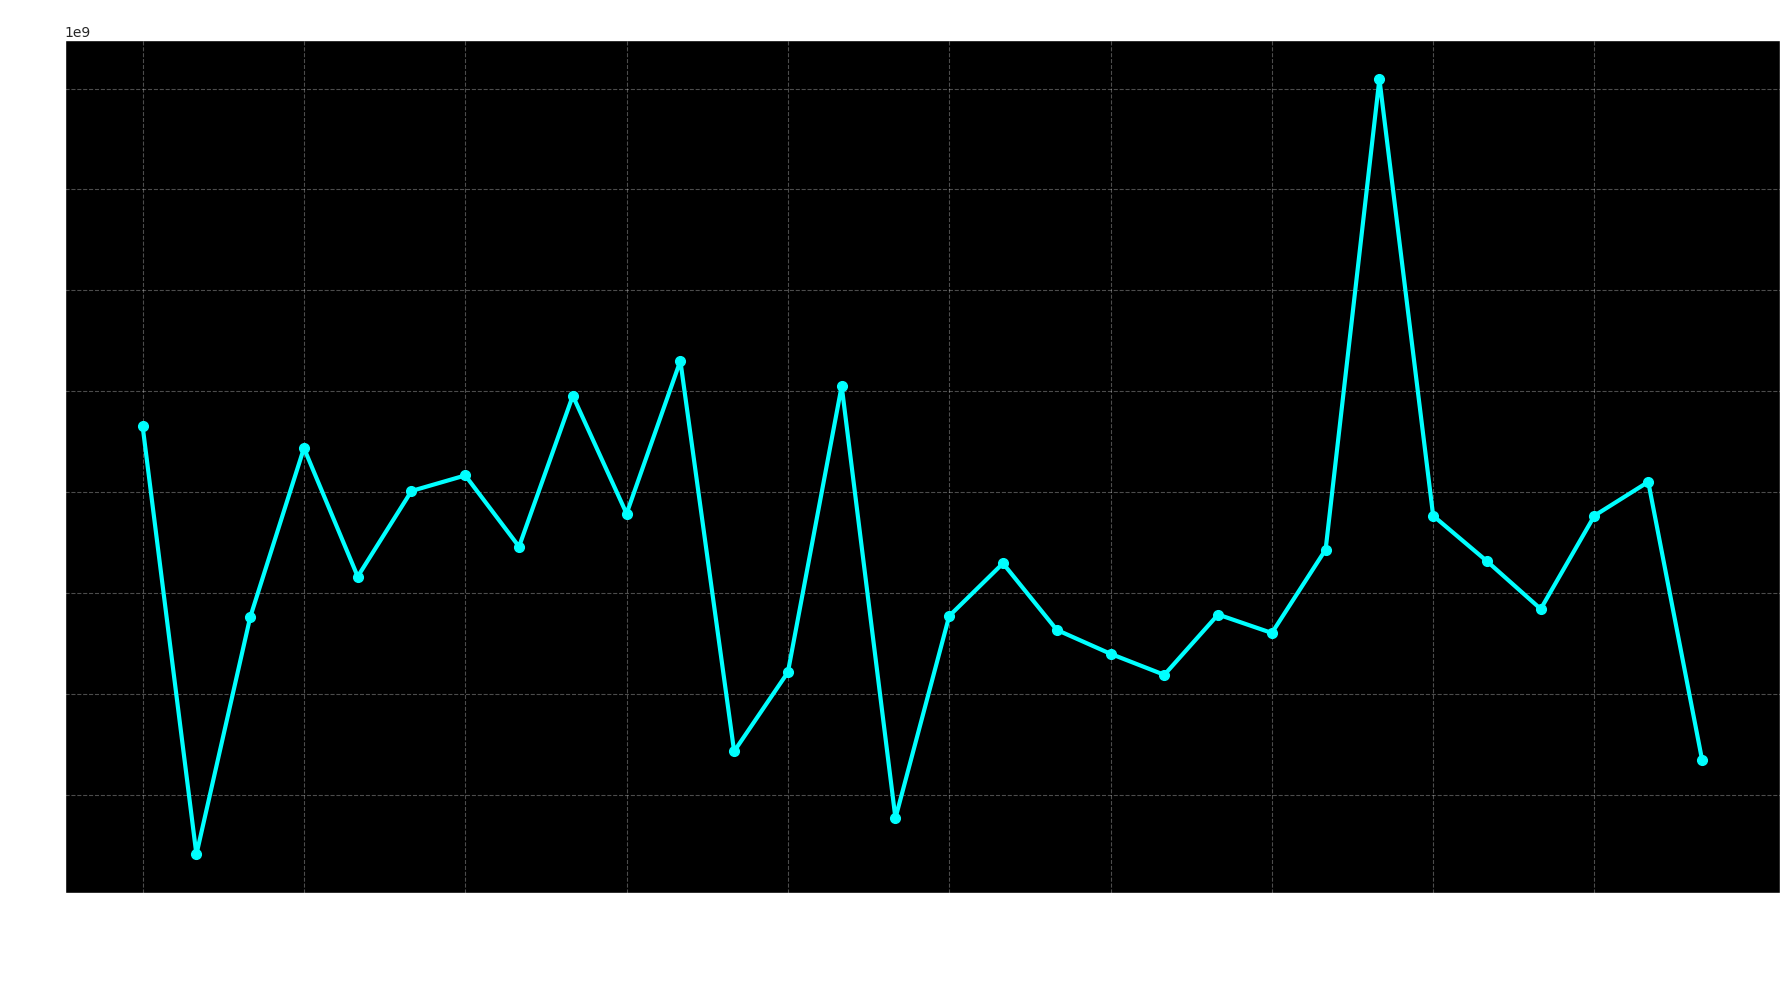

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files
from pyspark.sql.functions import sum

# Style global dark
plt.style.use("dark_background")
sns.set_style("dark")

# Agrégation
ca_time = df_clean.groupBy("year", "month") \
    .agg(sum("total_revenue").alias("revenue")) \
    .orderBy("year", "month")

# Conversion pandas
pdf_ca = ca_time.toPandas()
pdf_ca["period"] = pdf_ca["year"].astype(str) + "-" + pdf_ca["month"].astype(str).str.zfill(2)

# Graphique
plt.figure(figsize=(18,10))
plt.plot(
    pdf_ca["period"],
    pdf_ca["revenue"],
    marker="o",
    linewidth=3,
    markersize=7,
    color="#00FFFF"
)

plt.title("Évolution du chiffre d'affaires du Lamb", fontsize=22, color="white", weight="bold")
plt.xlabel("Période", fontsize=15, color="white")
plt.ylabel("Revenu total", fontsize=15, color="white")

plt.xticks(
    range(0, len(pdf_ca["period"]), 3),
    pdf_ca["period"][::3],
    rotation=45,
    fontsize=11,
    color="white"
)
plt.yticks(fontsize=11, color="white")

plt.grid(True, linestyle="--", alpha=0.3)
plt.gca().set_facecolor("black")

plt.tight_layout()

# Sauvegarde HD
plt.savefig(
    "evolution_CA_dark_HD.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Téléchargement
files.download("evolution_CA_dark_HD.png")

Les fortes variations montrent une dépendance à quelques événements clés, ce qui traduit une concentration de l’activité économique autour des combats les plus importants.

Partie 2: Top Lutteurs

On veut identifier les lutteurs qui génèrent le plus de revenus.
 Cela permet de voir si l’économie du lamb est dominée par quelques figures importantes.

Dictionnaire des lutteurs

In [ ]:
wrestler_names = {
    0: "Balla Gaye 2",
    1: "Modou Lo",
    2: "Eumeu Sène",
    3: "Bombardier",
    4: "Lac 2",
    5: "Gris Bordeaux",
    6: "Tapha Tine",
    7: "Ama Baldé",
    8: "Boy Niang 2",
    9: "Reug Reug",
    10: "Sa Thiès",
    11: "Gouye Gui",
    12: "Zarco",
    13: "Papa Sow",
    14: "Forza",
    15: "Less 2"
}

In [ ]:
from pyspark.sql.functions import col
df_lutteurs = df_clean.filter(col("winner").isNotNull())

In [ ]:
from pyspark.sql.functions import col, when, create_map, lit
from itertools import chain

mapping_expr = create_map([lit(x) for x in chain(*wrestler_names.items())])

df_clean = df_clean.withColumn(
    "winner_name",
    when(col("winner").isNull(), "Nul/Annulé")
    .otherwise(mapping_expr[col("winner")])
)

df_clean.select("winner", "winner_name").show(10, truncate=False)

+------+-----------+
|winner|winner_name|
+------+-----------+
|NULL  |Nul/Annulé |
|15    |Less 2     |
|9     |Reug Reug  |
|14    |Forza      |
|6     |Tapha Tine |
|NULL  |Nul/Annulé |
|8     |Boy Niang 2|
|3     |Bombardier |
|NULL  |Nul/Annulé |
|NULL  |Nul/Annulé |
+------+-----------+
only showing top 10 rows


In [ ]:
from pyspark.sql.functions import sum, desc

top_lutteurs = df_clean.groupBy("winner_name") \
    .agg(sum("total_revenue").alias("revenu_total")) \
    .orderBy(desc("revenu_total")) \
    .limit(10)

top_lutteurs.show(truncate=False)

+-------------+-------------+
|winner_name  |revenu_total |
+-------------+-------------+
|Nul/Annulé   |7.052169791E9|
|Bombardier   |1.502953557E9|
|Sa Thiès     |1.162039833E9|
|Modou Lo     |1.09233031E9 |
|Reug Reug    |1.046644948E9|
|Papa Sow     |1.033706636E9|
|Ama Baldé    |9.78712432E8 |
|Zarco        |9.54993978E8 |
|Boy Niang 2  |9.29511311E8 |
|Gris Bordeaux|9.16579543E8 |
+-------------+-------------+



In [ ]:
from pyspark.sql.functions import sum, desc

top_lutteurs = df_lutteurs.groupBy("winner_name") \
    .agg(sum("total_revenue").alias("revenu_total")) \
    .orderBy(desc("revenu_total")) \
    .limit(10)

top_lutteurs.show(truncate=False)

+-------------+-------------+
|winner_name  |revenu_total |
+-------------+-------------+
|Bombardier   |1.502953557E9|
|Sa Thiès     |1.162039833E9|
|Modou Lo     |1.09233031E9 |
|Reug Reug    |1.046644948E9|
|Papa Sow     |1.033706636E9|
|Ama Baldé    |9.78712432E8 |
|Zarco        |9.54993978E8 |
|Boy Niang 2  |9.29511311E8 |
|Gris Bordeaux|9.16579543E8 |
|Tapha Tine   |8.83202578E8 |
+-------------+-------------+



In [ ]:
pdf_top_lutteurs = top_lutteurs.toPandas()
pdf_top_lutteurs

,winner_name,revenu_total
0,Bombardier,1.502954e+09
1,Sa Thiès,1.162040e+09
2,Modou Lo,1.092330e+09
3,Reug Reug,1.046645e+09
4,Papa Sow,1.033707e+09
5,Ama Baldé,9.787124e+08
6,Zarco,9.549940e+08
7,Boy Niang 2,9.295113e+08
8,Gris Bordeaux,9.165795e+08
9,Tapha Tine,8.832026e+08


Visualisation 2: Top Lutteur

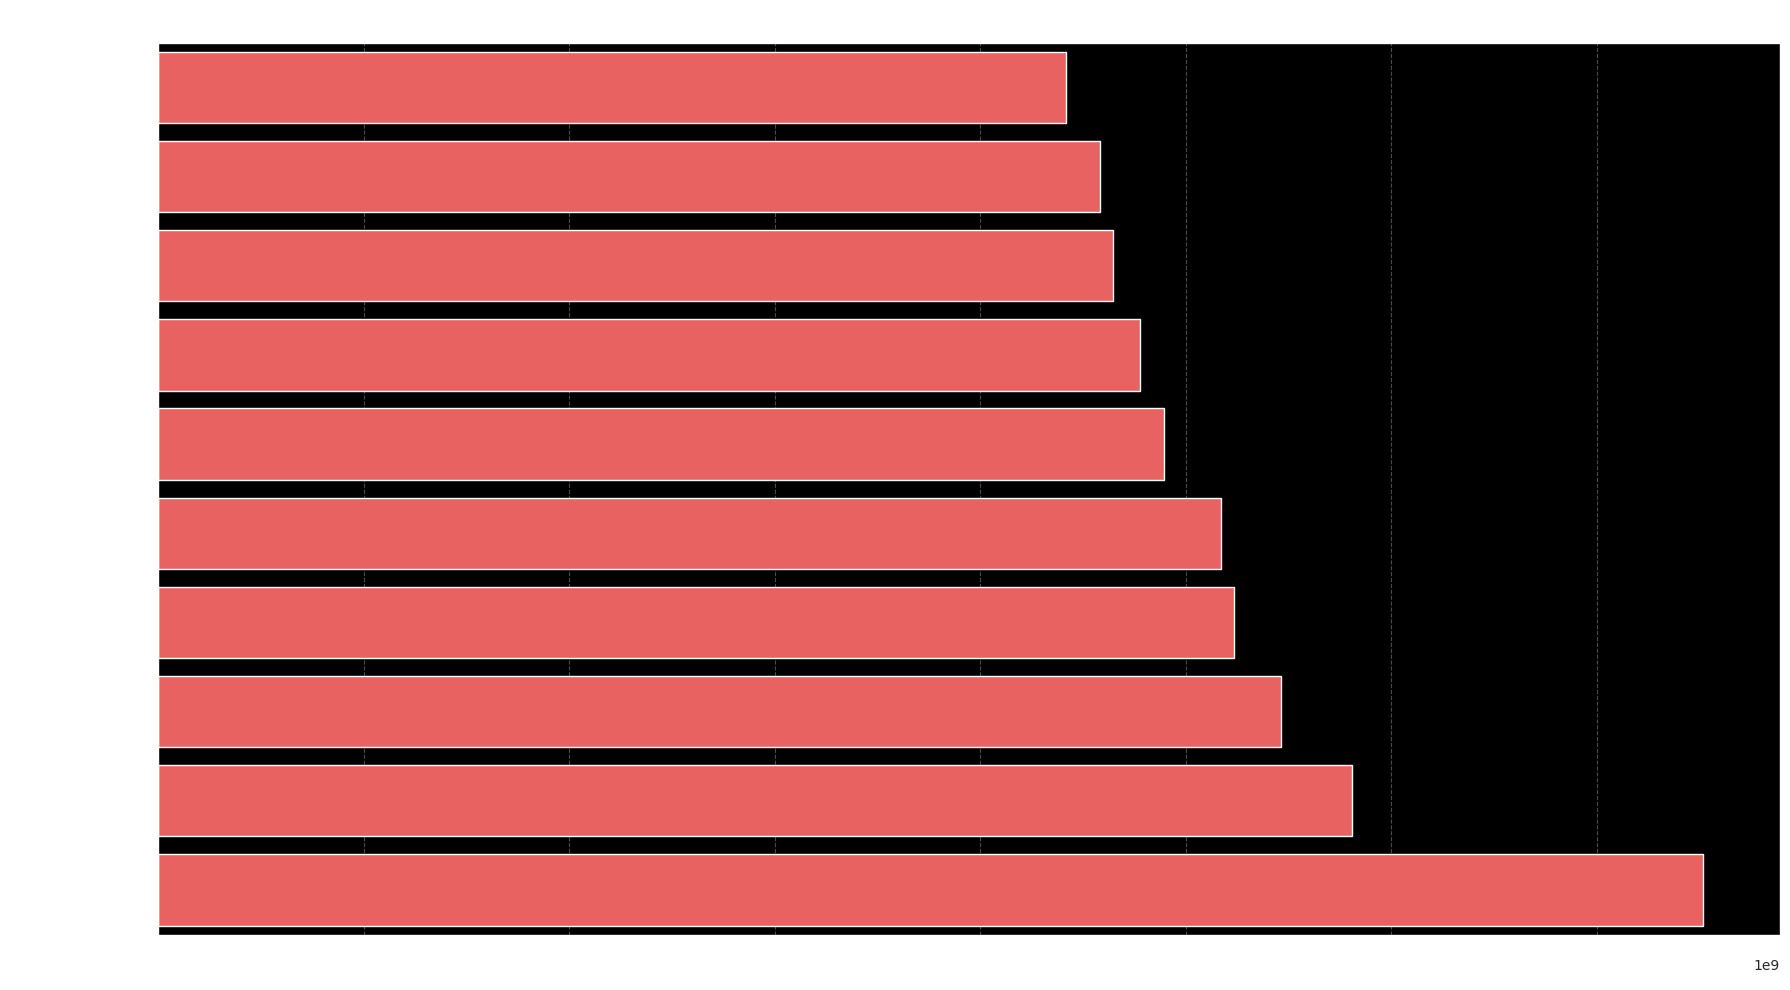

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from pyspark.sql.functions import sum, desc, col

# Style global dark
plt.style.use("dark_background")
sns.set_style("dark")

# Exclure les combats annulés
df_lutteurs = df_clean.filter(col("winner").isNotNull())

# Top 10
top_lutteurs = df_lutteurs.groupBy("winner_name") \
    .agg(sum("total_revenue").alias("revenu_total")) \
    .orderBy(desc("revenu_total")) \
    .limit(10)

# Conversion pandas
pdf_top_lutteurs = top_lutteurs.toPandas()
pdf_top_lutteurs = pdf_top_lutteurs.sort_values("revenu_total", ascending=True)

# Graphique
plt.figure(figsize=(18,10))
sns.barplot(
    data=pdf_top_lutteurs,
    x="revenu_total",
    y="winner_name",
    color="#FF4C4C"
)

plt.title("Top 10 des lutteurs par revenu généré", fontsize=22, color="white", weight="bold")
plt.xlabel("Revenu total", fontsize=15, color="white")
plt.ylabel("Lutteur", fontsize=15, color="white")

plt.xticks(fontsize=11, color="white")
plt.yticks(fontsize=12, color="white")

plt.grid(True, axis="x", linestyle="--", alpha=0.3)
plt.gca().set_facecolor("black")

plt.tight_layout()

# Sauvegarde HD
plt.savefig(
    "top_lutteurs_dark_HD.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Téléchargement
files.download("top_lutteurs_dark_HD.png")

In [ ]:
from google.colab import files
files.download("graph2_lutteurs_noms.png")

FileNotFoundError: Cannot find file: graph2_lutteurs_noms.png

Selon notre analyse, Bombardier est le lutteur qui génère le plus de revenus, suivi de Sa Thiès. Cela montre que certaines figures dominent économiquement le secteur, même si cela ne reflète pas forcément le classement sportif réel.”

Partie 3: Revenu par Arène

In [ ]:
from pyspark.sql.functions import sum, desc

arena_revenue = df_clean.groupBy("arena") \
    .agg(sum("total_revenue").alias("revenu_total")) \
    .orderBy(desc("revenu_total"))

arena_revenue.show()

+----------------+-------------+
|           arena| revenu_total|
+----------------+-------------+
|  Arène inconnue|7.763759279E9|
| Arène nationale|7.200407776E9|
|Stade Demba Diop|7.027670151E9|
+----------------+-------------+



In [ ]:
pdf_arena = arena_revenue.toPandas()
pdf_arena

,arena,revenu_total
0,Arène inconnue,7.763759e+09
1,Arène nationale,7.200408e+09
2,Stade Demba Diop,7.027670e+09


Visualisation 3

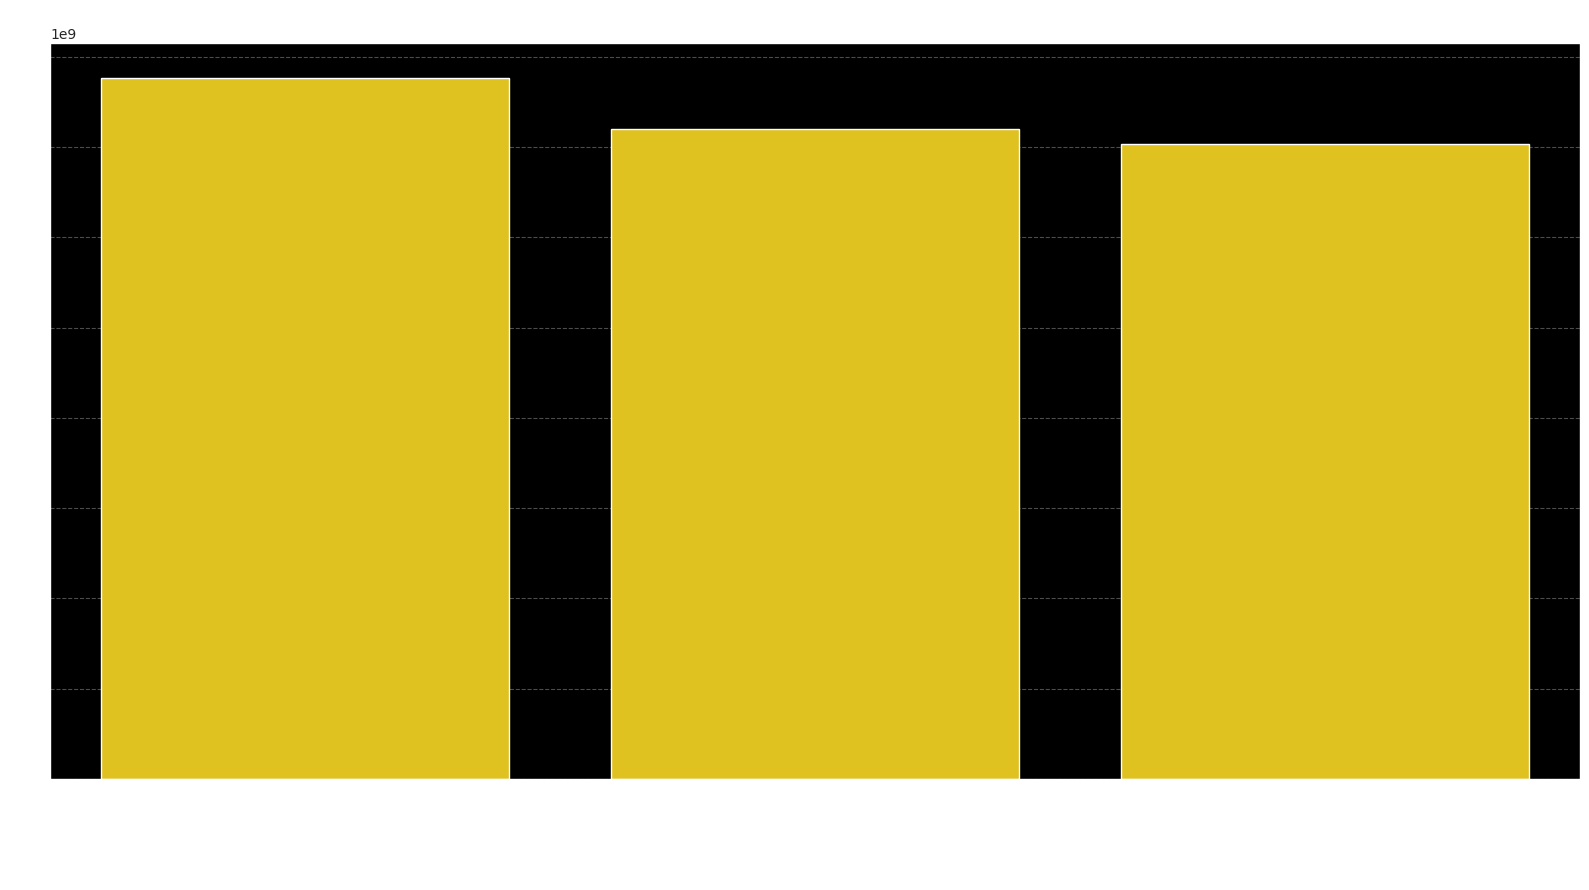

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from pyspark.sql.functions import sum, desc

# Style global dark
plt.style.use("dark_background")
sns.set_style("dark")

# Agrégation
arena_revenue = df_clean.groupBy("arena") \
    .agg(sum("total_revenue").alias("revenu_total")) \
    .orderBy(desc("revenu_total"))

# Conversion pandas
pdf_arena = arena_revenue.toPandas()

# Graphique
plt.figure(figsize=(16,9))
sns.barplot(
    data=pdf_arena,
    x="arena",
    y="revenu_total",
    color="#FFD700"
)

plt.title("Revenus par arène", fontsize=22, color="white", weight="bold")
plt.xlabel("Arène", fontsize=15, color="white")
plt.ylabel("Revenu total", fontsize=15, color="white")

plt.xticks(rotation=20, fontsize=12, color="white")
plt.yticks(fontsize=11, color="white")

plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.gca().set_facecolor("black")

plt.tight_layout()

# Sauvegarde HD
plt.savefig(
    "revenus_arene_dark_HD.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Téléchargement
files.download("revenus_arene_dark_HD.png")

In [ ]:
from google.colab import files
files.download("graph3_arena.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


L’analyse des revenus par arène montre que la catégorie “Arène inconnue” génère les revenus les plus élevés dans le dataset. Toutefois, cette catégorie ne correspond pas nécessairement à une arène spécifique, mais peut regrouper des combats locaux ou traditionnels.

Dans le contexte sénégalais, ces combats peuvent inclure des formes de rémunération non monétaires (maisons, bétail, véhicules, etc.), ce qui peut influencer le niveau de revenus observé. Par conséquent, cette catégorie mélange plusieurs types d’événements et doit être interprétée avec prudence.

Ainsi, bien que les arènes officielles comme l’Arène nationale et le Stade Demba Diop restent des lieux majeurs du lamb professionnel, la présence d’une catégorie “inconnue” met en évidence une limite du dataset et souligne la nécessité de mieux distinguer les types de combats pour une analyse plus précise.

Partie 4: Ventes de tickets

Le revenu moyen par tranche de ticket



In [ ]:
from pyspark.sql.functions import when

df_bins = df_clean.withColumn(
    "ticket_range",
    when(df_clean.tickets_sold < 5000, "0-5k")
    .when((df_clean.tickets_sold >= 5000) & (df_clean.tickets_sold < 10000), "5k-10k")
    .when((df_clean.tickets_sold >= 10000) & (df_clean.tickets_sold < 15000), "10k-15k")
    .otherwise("15k+")
)

df_bins.select("tickets_sold", "ticket_range", "total_revenue").show(10, truncate=False)

+------------+------------+-------------+
|tickets_sold|ticket_range|total_revenue|
+------------+------------+-------------+
|14087       |10k-15k     |3536646.0    |
|6242        |5k-10k      |1.2399762E7  |
|19128       |15k+        |596309.0     |
|8892        |5k-10k      |1.8230034E7  |
|4224        |0-5k        |5.0935907E7  |
|19173       |15k+        |3.9507978E7  |
|9924        |5k-10k      |4.098975E7   |
|8457        |5k-10k      |2370018.0    |
|18036       |15k+        |3.2416174E7  |
|5170        |5k-10k      |2109271.0    |
+------------+------------+-------------+
only showing top 10 rows


Calcul du revenu moyen

In [ ]:
from pyspark.sql.functions import avg

revenue_by_range = df_bins.groupBy("ticket_range") \
    .agg(avg("total_revenue").alias("revenu_moyen")) \
    .orderBy("ticket_range")

revenue_by_range.show(truncate=False)

+------------+--------------------+
|ticket_range|revenu_moyen        |
+------------+--------------------+
|0-5k        |1.0581529352941176E7|
|10k-15k     |1.1477568922787193E7|
|15k+        |9888951.158396946   |
|5k-10k      |1.2004774805168986E7|
+------------+--------------------+



In [ ]:
pdf_range = revenue_by_range.toPandas()
pdf_range

,ticket_range,revenu_moyen
0,0-5k,1.058153e+07
1,10k-15k,1.147757e+07
2,15k+,9.888951e+06
3,5k-10k,1.200477e+07


Scatter plot

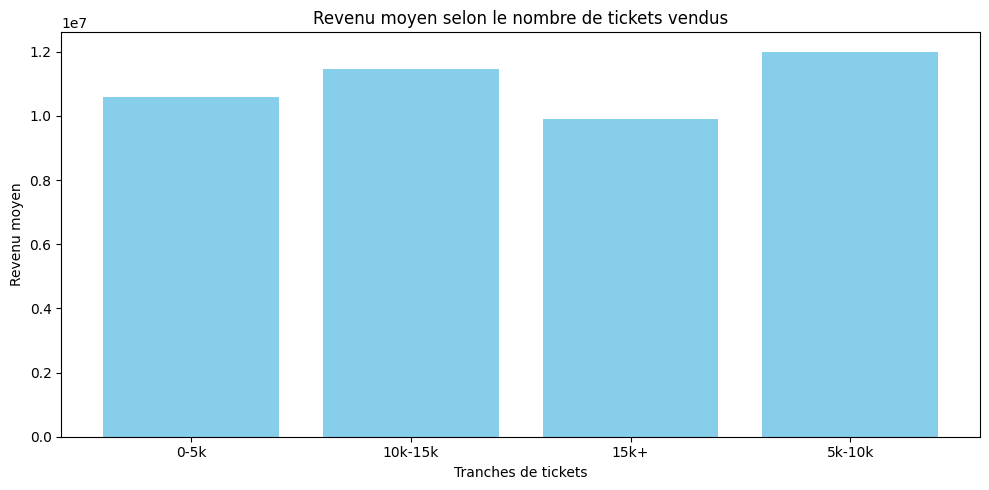

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from google.colab import files
from pyspark.sql.functions import when, avg

# Style global dark
plt.style.use("dark_background")
sns.set_style("dark")

# Création des tranches
df_bins = df_clean.withColumn(
    "ticket_range",
    when(df_clean.tickets_sold < 5000, "0-5k")
    .when((df_clean.tickets_sold >= 5000) & (df_clean.tickets_sold < 10000), "5k-10k")
    .when((df_clean.tickets_sold >= 10000) & (df_clean.tickets_sold < 15000), "10k-15k")
    .otherwise("15k+")
)

# Calcul du revenu moyen
revenue_by_range = df_bins.groupBy("ticket_range") \
    .agg(avg("total_revenue").alias("revenu_moyen"))

# Conversion pandas
pdf_range = revenue_by_range.toPandas()

# Ordre logique
ordre = ["0-5k", "5k-10k", "10k-15k", "15k+"]
pdf_range["ticket_range"] = pd.Categorical(pdf_range["ticket_range"], categories=ordre, ordered=True)
pdf_range = pdf_range.sort_values("ticket_range")

# Graphique
plt.figure(figsize=(14,8))
plt.bar(
    pdf_range["ticket_range"],
    pdf_range["revenu_moyen"],
    color="#00FF7F"
)

plt.title("Revenu moyen selon le nombre de tickets vendus", fontsize=20, color="white", weight="bold")
plt.xlabel("Tranches de tickets", fontsize=14, color="white")
plt.ylabel("Revenu moyen", fontsize=14, color="white")

plt.xticks(fontsize=12, color="white")
plt.yticks(fontsize=11, color="white")

plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.gca().set_facecolor("black")

plt.tight_layout()

# Sauvegarde HD
plt.savefig(
    "revenu_par_tranche_dark_HD.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Téléchargement
files.download("revenu_par_tranche_dark_HD.png")

In [ ]:
from google.colab import files
files.download("graph_revenu_tickets.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


On observe que le revenu moyen augmente globalement avec le nombre de tickets vendus.  

Les combats ayant une forte affluence (plus de 10 000 tickets) génèrent en moyenne des revenus plus élevés que ceux avec une faible affluence.  

Cependant, certaines variations existent, ce qui suggère que d’autres facteurs, comme les sponsors ou la popularité des lutteurs, influencent également les revenus.